# Entrenando a un sommelier

Predecir color y calidad del vino con sus variables fisicoquimicas (dataset Wine Quality, UCI).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)
sns.set_style("whitegrid")

/Users/ignacioaracena/Projects/Data-Science/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Entender el problema

El color deberia ser facil; la calidad, mas dificil (ordinal y desbalanceada).

## 2. Los datos

In [2]:
red = pd.read_csv("data/winequality-red.csv", sep=";")
white = pd.read_csv("data/winequality-white.csv", sep=";")
red["color"] = "red"
white["color"] = "white"
df = pd.concat([red, white], ignore_index=True)
df.columns = [c.replace(" ", "_") for c in df.columns]
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [3]:
df.shape, df["color"].value_counts().to_dict(), df.isnull().sum().sum()

((6497, 13), {'white': 4898, 'red': 1599}, 0)

In [4]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(5320, 13)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,5320.0,7.215179,1.319671,3.80000,6.4000,7.00000,7.70000,15.90000
volatile_acidity,5320.0,0.344130,0.168248,0.08000,0.2300,0.30000,0.41000,1.58000
citric_acid,5320.0,0.318494,0.147157,0.00000,0.2400,0.31000,0.40000,1.66000
residual_sugar,5320.0,5.048477,4.500180,0.60000,1.8000,2.70000,7.50000,65.80000
chlorides,5320.0,0.056690,0.036863,0.00900,0.0380,0.04700,0.06600,0.61100
free_sulfur_dioxide,5320.0,30.036654,17.805045,1.00000,16.0000,28.00000,41.00000,289.00000
total_sulfur_dioxide,5320.0,114.109023,56.774223,6.00000,74.0000,116.00000,153.25000,440.00000
density,5320.0,0.994535,0.002966,0.98711,0.9922,0.99465,0.99677,1.03898
pH,5320.0,3.224664,0.160379,2.72000,3.1100,3.21000,3.33000,4.01000
sulphates,5320.0,0.533357,0.149743,0.22000,0.4300,0.51000,0.60000,2.00000


In [6]:
df["quality"].value_counts().sort_index()

quality
3      30
4     206
5    1752
6    2323
7     856
8     148
9       5
Name: count, dtype: int64

In [7]:
features = [c for c in df.columns if c not in ("quality", "color")]
features

['fixed_acidity',
 'volatile_acidity',
 'citric_acid',
 'residual_sugar',
 'chlorides',
 'free_sulfur_dioxide',
 'total_sulfur_dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol']

### Distribuciones por color

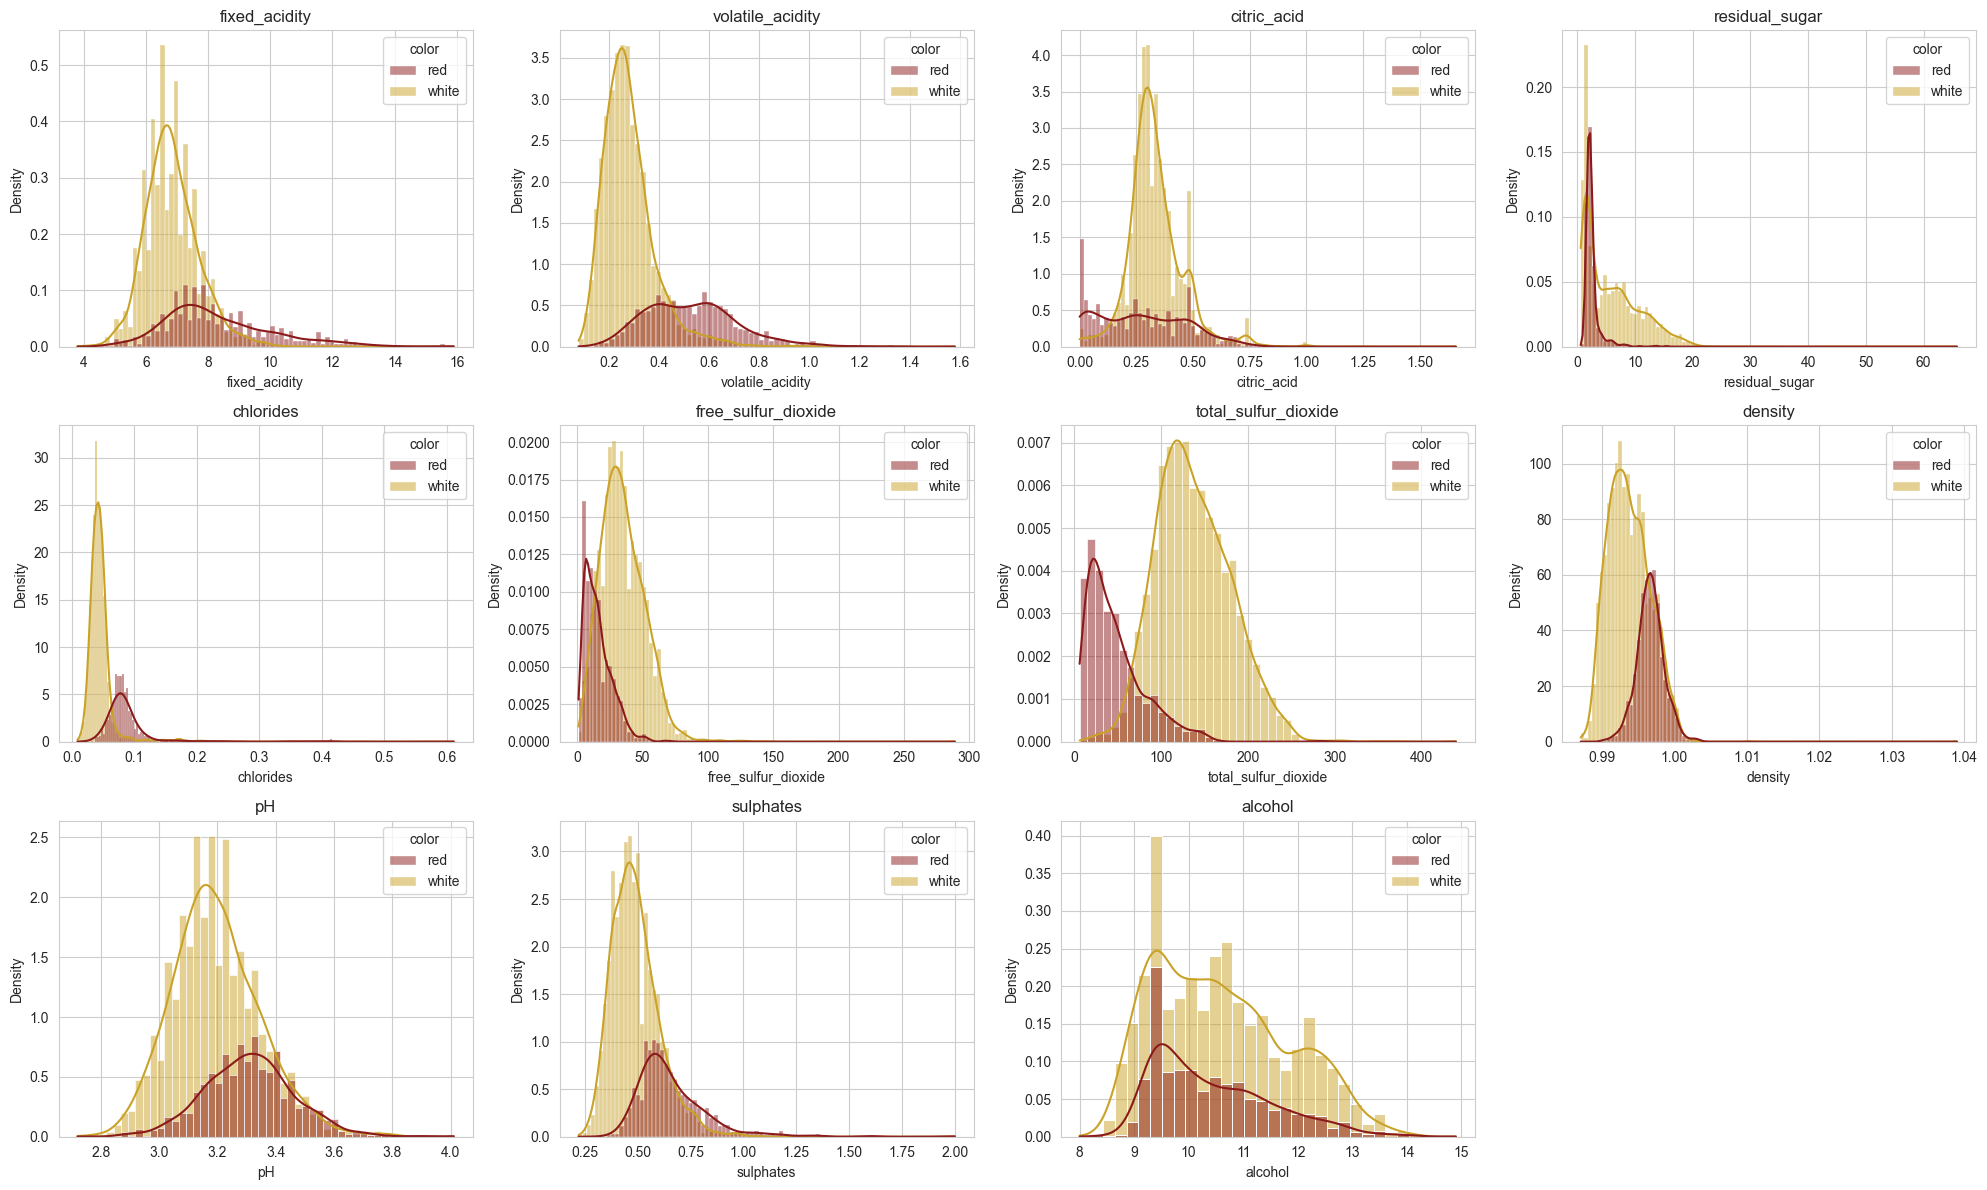

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, c in zip(axes.ravel(), features):
    sns.histplot(data=df, x=c, hue="color", kde=True, stat="density",
                 palette={"red": "#8b1a1a", "white": "#c9a227"}, alpha=0.5, ax=ax)
    ax.set_title(c)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

### Boxplots por color

/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_24026/254824911.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="color", y=c, palette={"red": "#8b1a1a", "white": "#c9a227"}, ax=ax)
/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_24026/254824911.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="color", y=c, palette={"red": "#8b1a1a", "white": "#c9a227"}, ax=ax)
/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_24026/254824911.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d

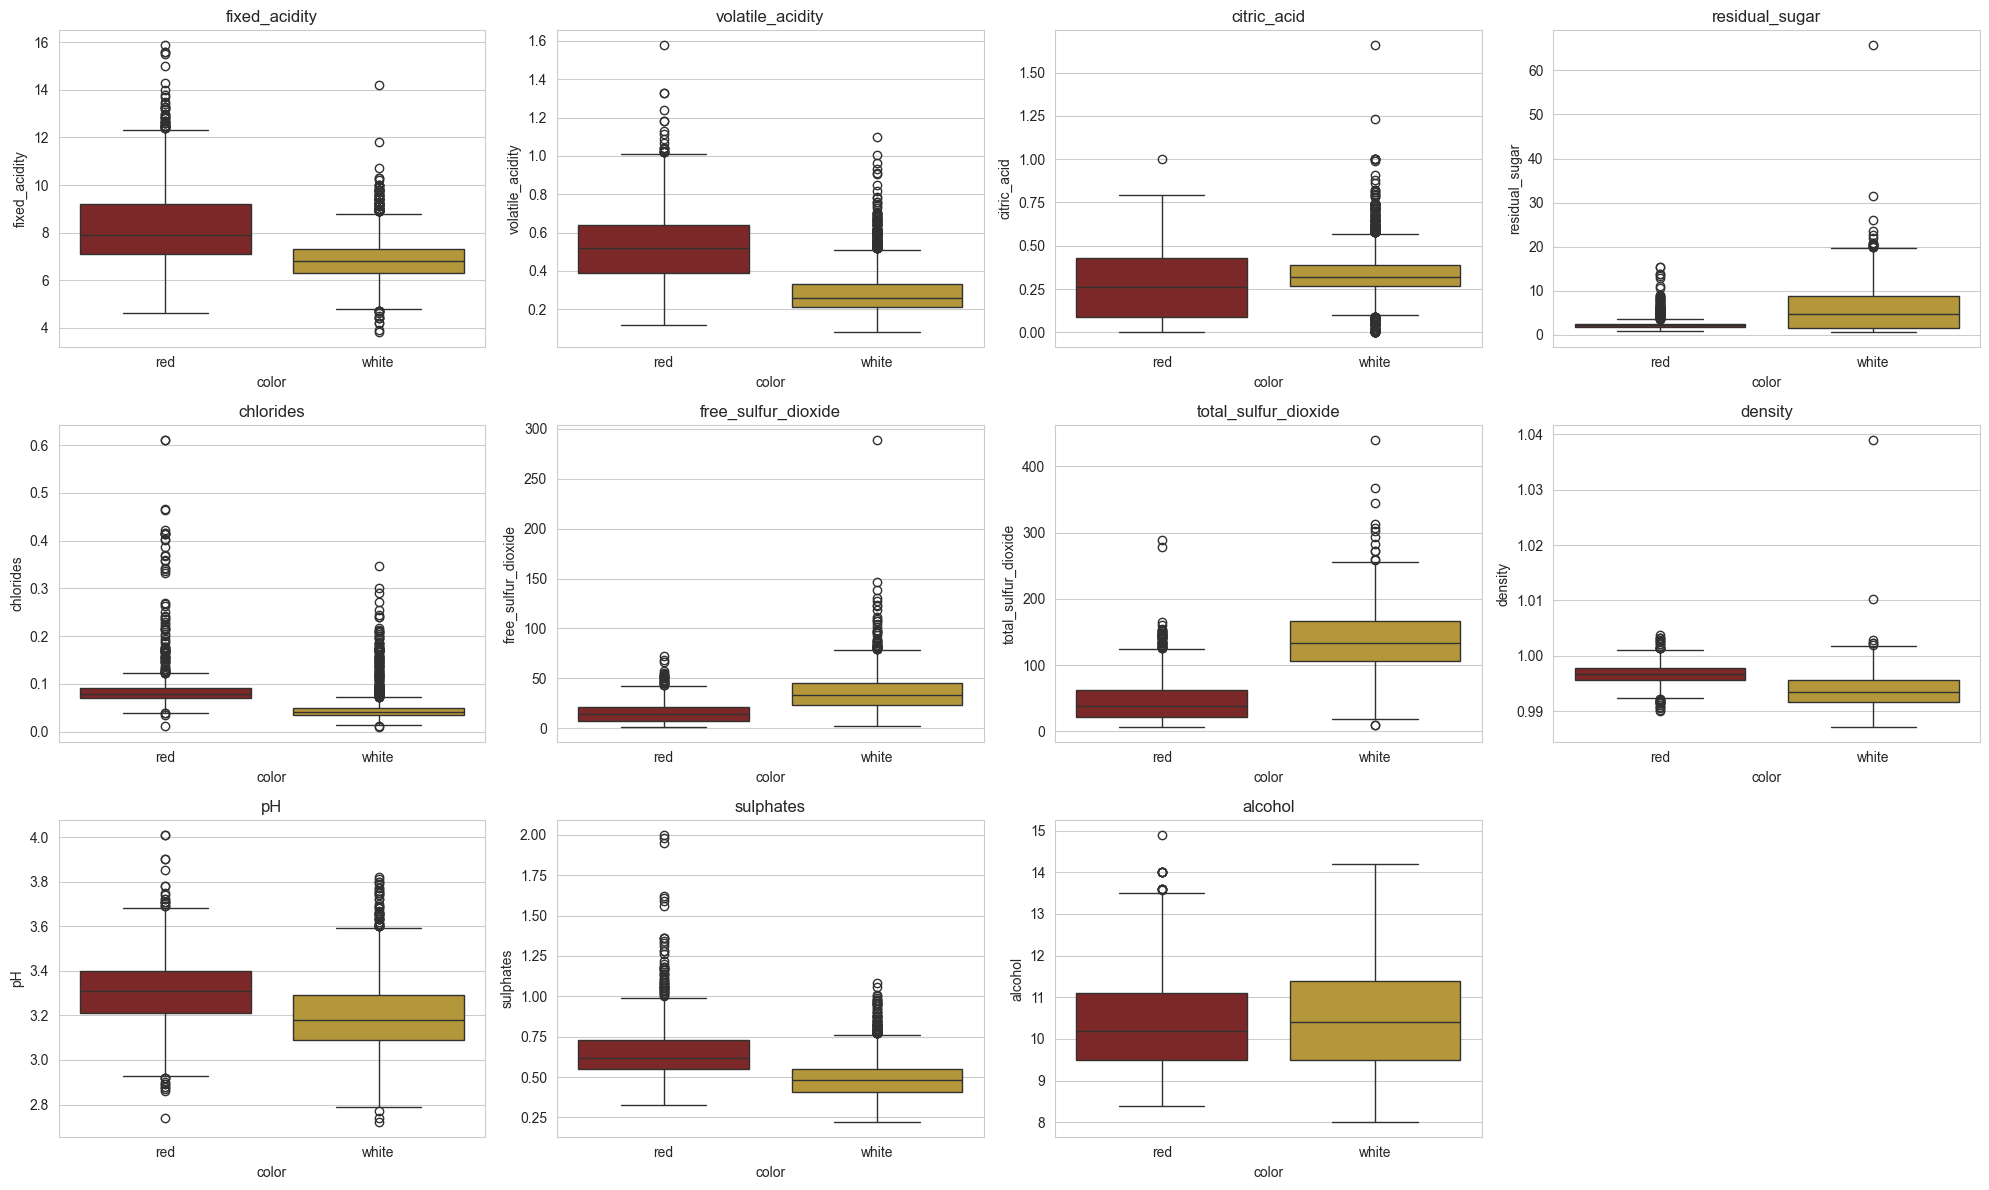

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, c in zip(axes.ravel(), features):
    sns.boxplot(data=df, x="color", y=c, palette={"red": "#8b1a1a", "white": "#c9a227"}, ax=ax)
    ax.set_title(c)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

### Boxplots por calidad

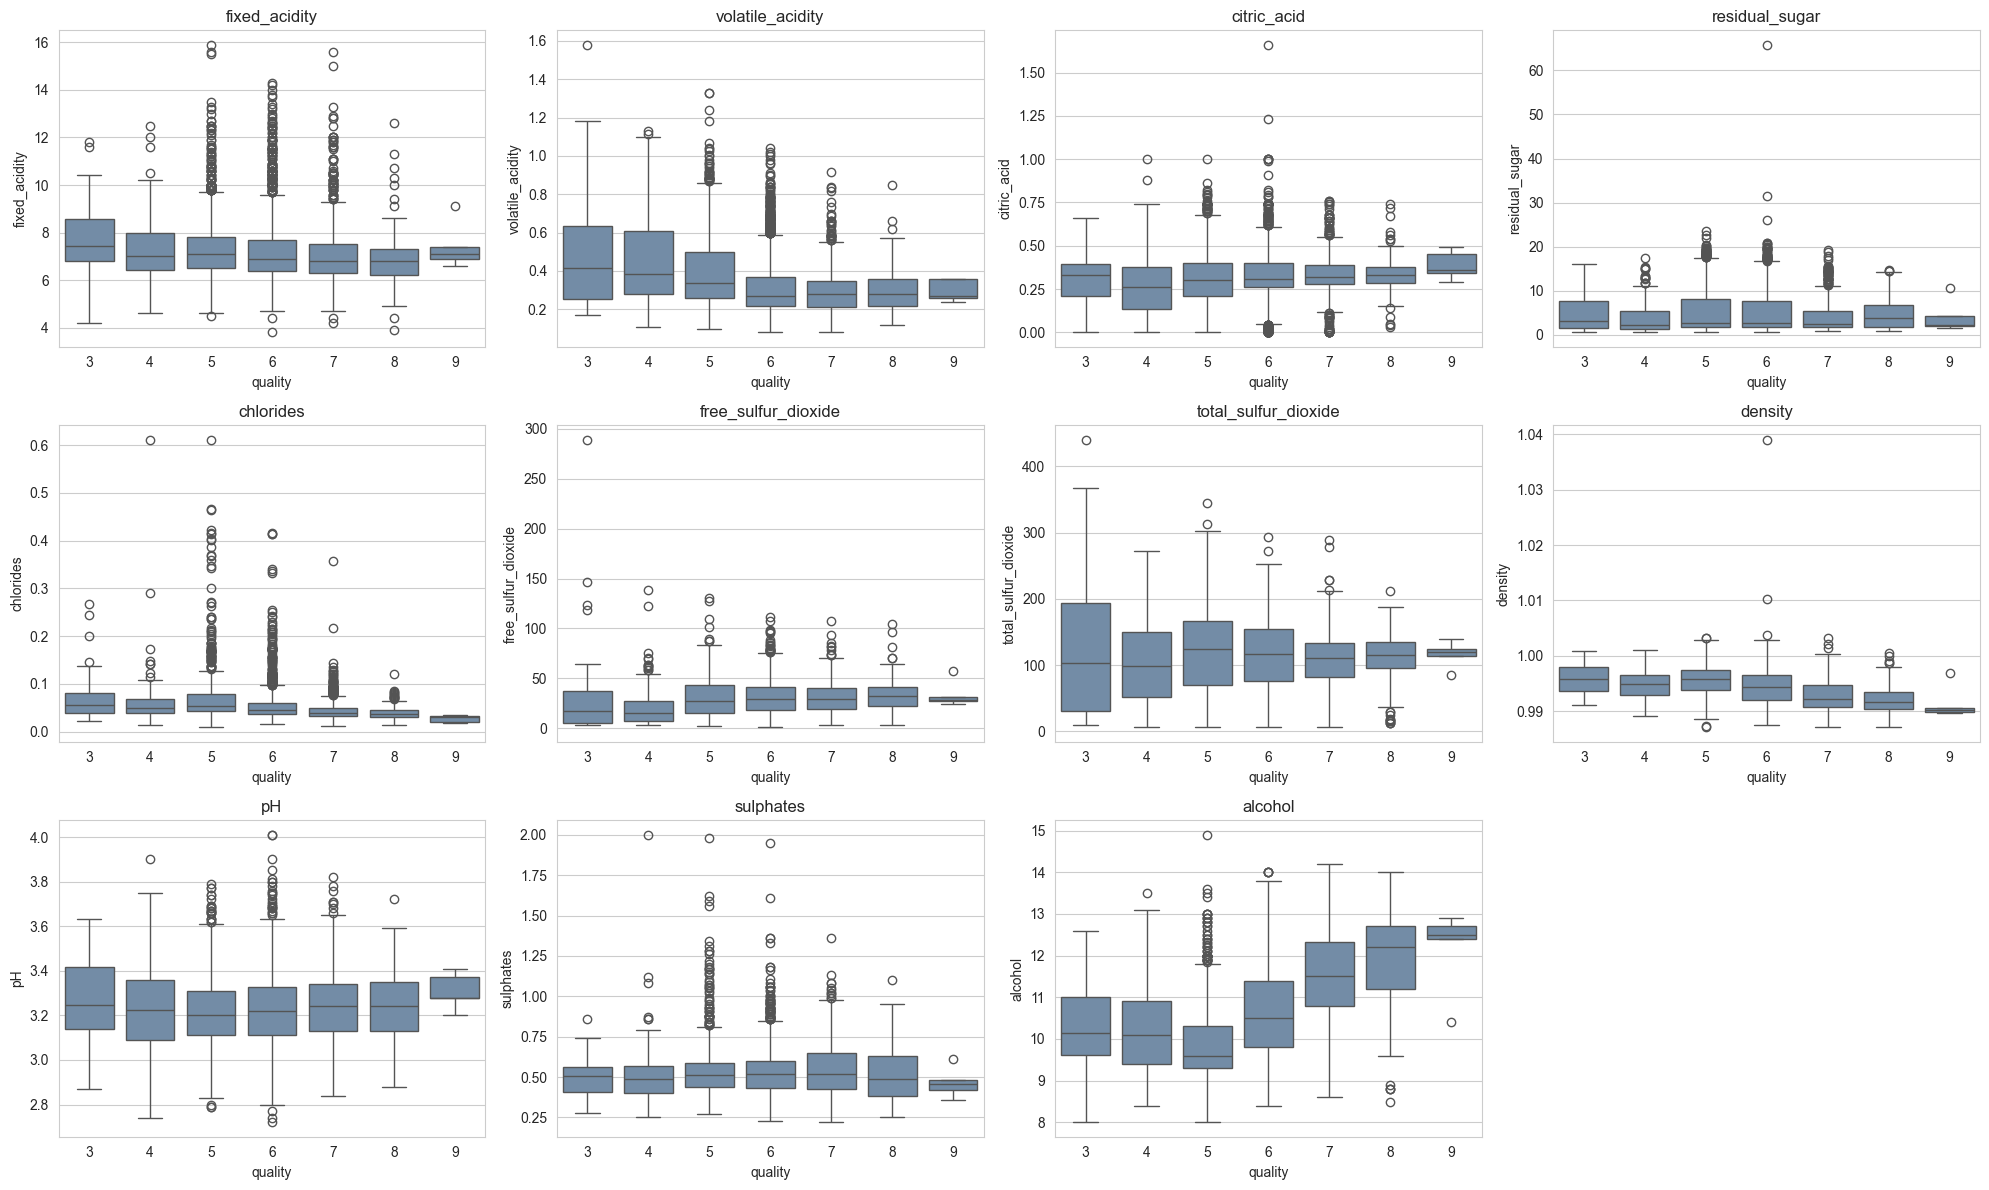

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, c in zip(axes.ravel(), features):
    sns.boxplot(data=df, x="quality", y=c, color="#6a8caf", ax=ax)
    ax.set_title(c)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

### Correlaciones

La calidad es ordinal: ademas de Pearson miramos Kendall.

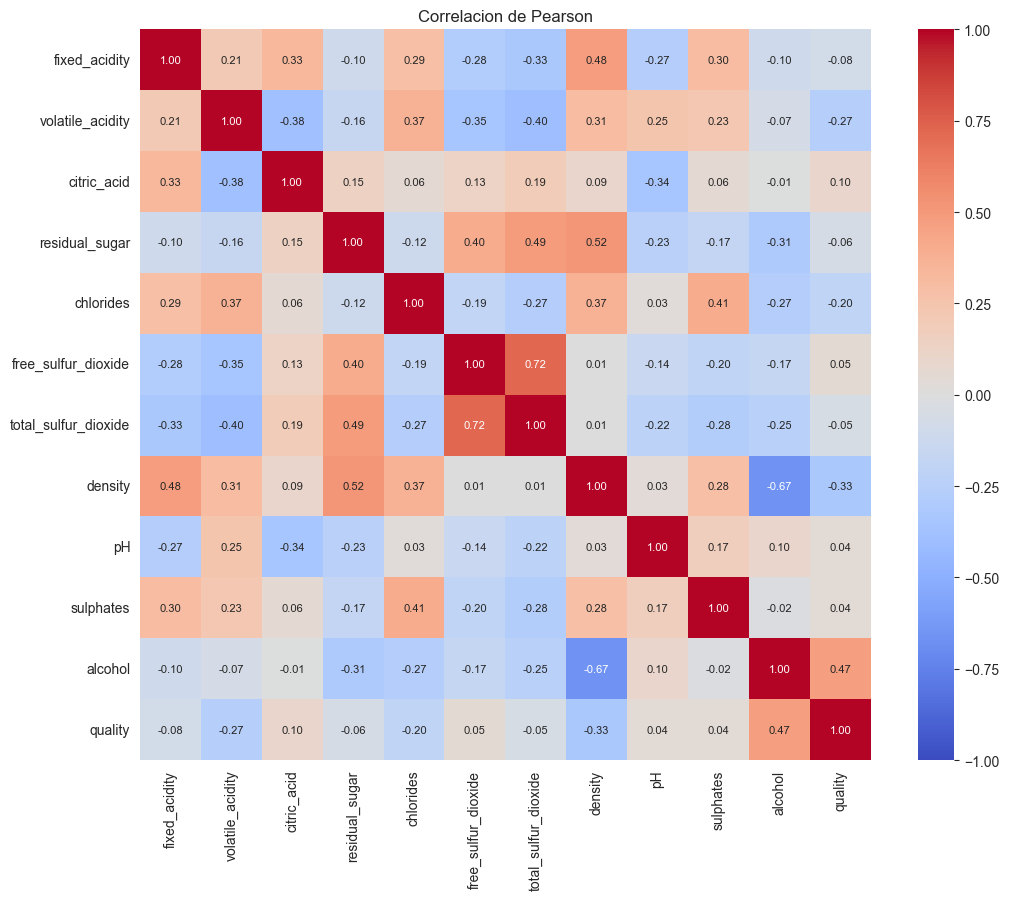

In [11]:
plt.figure(figsize=(11, 9))
sns.heatmap(df[features + ["quality"]].corr(), annot=True, cmap="coolwarm", fmt=".2f",
            vmin=-1, vmax=1, square=True, annot_kws={"size": 8})
plt.title("Correlacion de Pearson")
plt.tight_layout()
plt.show()

/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_24026/1369983756.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tau.values, y=tau.index, palette="vlag")


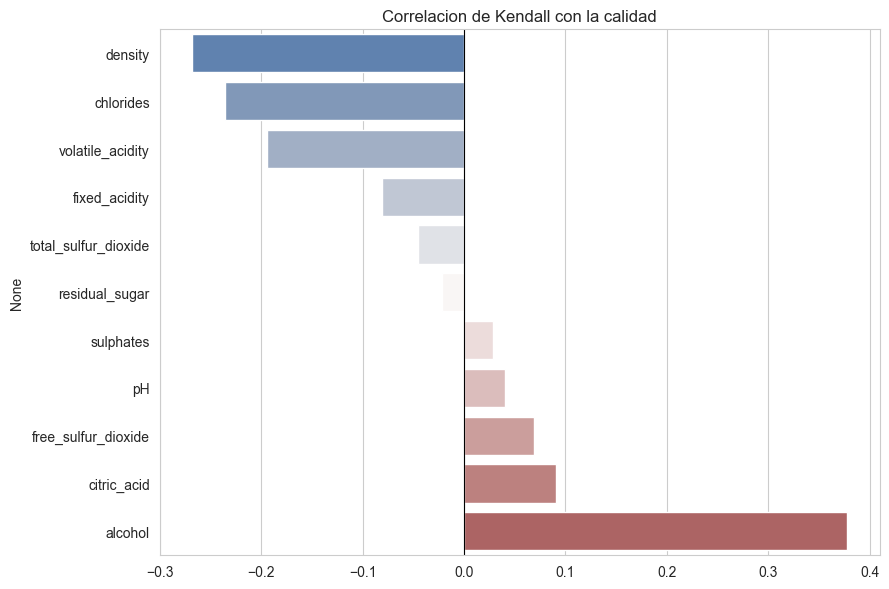

In [12]:
tau = df[features].apply(lambda col: stats.kendalltau(col, df["quality"]).correlation).sort_values()
plt.figure(figsize=(9, 6))
sns.barplot(x=tau.values, y=tau.index, palette="vlag")
plt.axvline(0, color="k", lw=0.8)
plt.title("Correlacion de Kendall con la calidad")
plt.tight_layout()
plt.show()

### Separabilidad del color

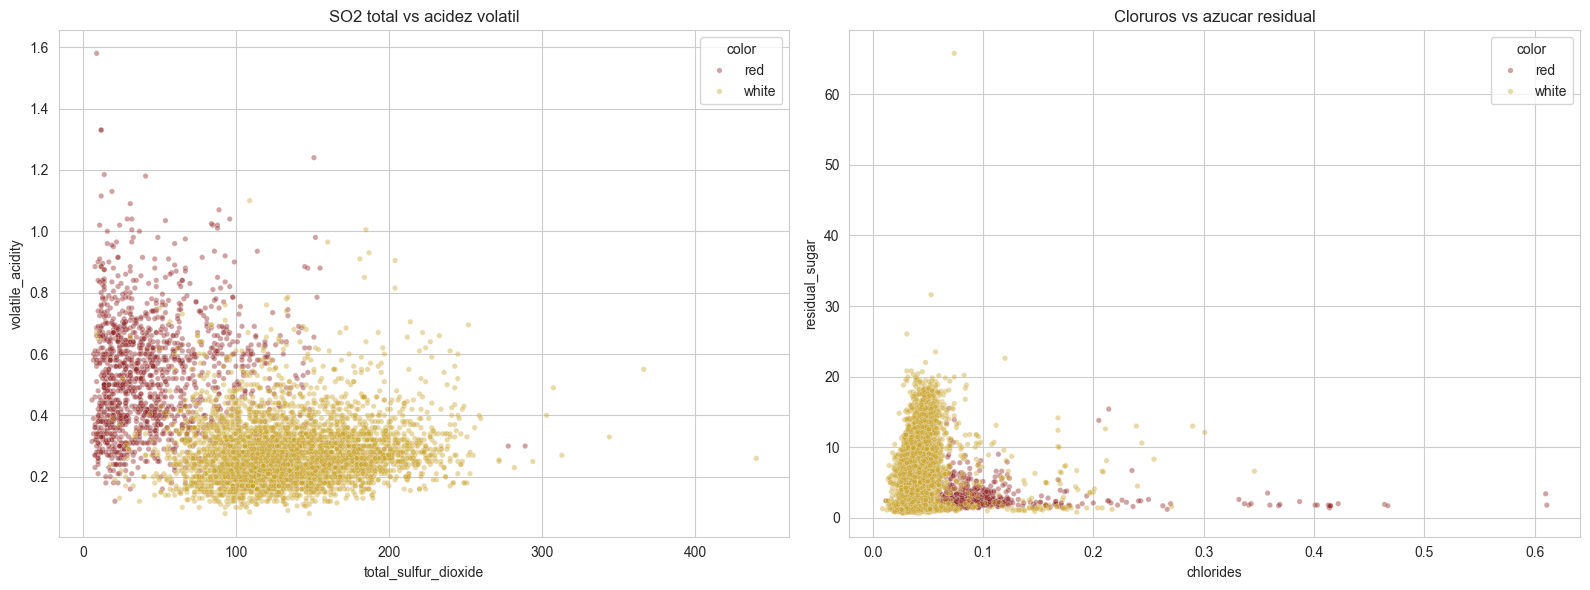

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=df, x="total_sulfur_dioxide", y="volatile_acidity", hue="color",
                palette={"red": "#8b1a1a", "white": "#c9a227"}, alpha=0.4, s=15, ax=axes[0])
axes[0].set_title("SO2 total vs acidez volatil")
sns.scatterplot(data=df, x="chlorides", y="residual_sugar", hue="color",
                palette={"red": "#8b1a1a", "white": "#c9a227"}, alpha=0.4, s=15, ax=axes[1])
axes[1].set_title("Cloruros vs azucar residual")
plt.tight_layout()
plt.show()

In [14]:
sample = df.sample(1500, random_state=42)
fig = px.scatter_3d(sample, x="total_sulfur_dioxide", y="volatile_acidity", z="alcohol",
                    color="color", opacity=0.6,
                    color_discrete_map={"red": "#8b1a1a", "white": "#c9a227"},
                    title="Vinos en 3D (muestra de 1500)")
fig.update_traces(marker_size=3)
fig.show()

## 3. Preparar los datos

Color: solo quimica, sin la calidad (seria trampa). Calidad: agrupada en baja, media y alta. Split 80/20 estratificado.

In [15]:
y_color = (df["color"] == "white").astype(int).values
X_color = df[features].values

def nivel(q):
    if q <= 4:
        return 0
    if q <= 6:
        return 1
    return 2

df["nivel"] = df["quality"].apply(nivel)
niveles = ["baja", "media", "alta"]
y_qual = df["nivel"].values
X_qual = df[features].values

df["nivel"].map(dict(enumerate(niveles))).value_counts()

nivel
media    4075
alta     1009
baja      236
Name: count, dtype: int64

In [16]:
from sklearn.model_selection import train_test_split

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X_color, y_color, test_size=0.2, stratify=y_color, random_state=42)
Xq_tr, Xq_te, yq_tr, yq_te = train_test_split(
    X_qual, y_qual, test_size=0.2, stratify=y_qual, random_state=42)
Xc_tr.shape, Xq_tr.shape

((4256, 11), (4256, 11))

Escalamos ajustando solo con el train, sin filtrar informacion.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler_c = StandardScaler()
Xc_tr_s = scaler_c.fit_transform(Xc_tr)
Xc_te_s = scaler_c.transform(Xc_te)

scaler_q = StandardScaler()
Xq_tr_s = scaler_q.fit_transform(Xq_tr)
Xq_te_s = scaler_q.transform(Xq_te)

## 4. Modelo de color

LogReg, KNN y Random Forest con validacion cruzada.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

modelos_color = {
    "LogReg": LogisticRegression(max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
}

filas = []
for nombre, m in modelos_color.items():
    cv = cross_val_score(m, Xc_tr_s, yc_tr, cv=5, scoring="f1_macro").mean()
    m.fit(Xc_tr_s, yc_tr)
    pred = m.predict(Xc_te_s)
    filas.append({"modelo": nombre,
                  "cv_f1": round(cv, 4),
                  "accuracy": round(accuracy_score(yc_te, pred), 4),
                  "f1_macro": round(f1_score(yc_te, pred, average="macro"), 4)})
tabla_color = pd.DataFrame(filas).sort_values("f1_macro", ascending=False).reset_index(drop=True)
tabla_color

,modelo,cv_f1,accuracy,f1_macro
0,RandomForest,0.9919,0.9944,0.9926
1,LogReg,0.9901,0.9934,0.9913
2,KNN,0.9898,0.9934,0.9913


In [19]:
rf_color = RandomForestClassifier(n_estimators=300, random_state=42).fit(Xc_tr_s, yc_tr)
pred_c = rf_color.predict(Xc_te_s)
print(classification_report(yc_te, pred_c, target_names=["red", "white"]))

              precision    recall  f1-score   support

         red       0.99      0.99      0.99       272
       white       0.99      1.00      1.00       792

    accuracy                           0.99      1064
   macro avg       0.99      0.99      0.99      1064
weighted avg       0.99      0.99      0.99      1064



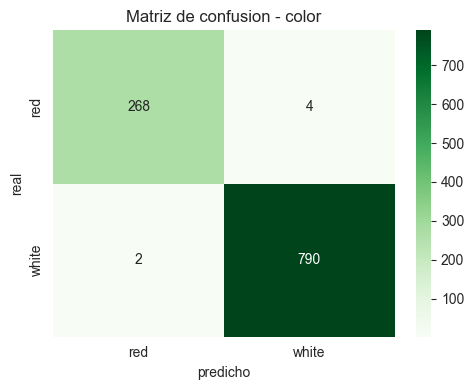

In [20]:
cm = confusion_matrix(yc_te, pred_c)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["red", "white"], yticklabels=["red", "white"])
plt.title("Matriz de confusion - color")
plt.ylabel("real"); plt.xlabel("predicho")
plt.tight_layout()
plt.show()

### Variables mas importantes para el color

/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_24026/2780354909.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette="Greens_d")


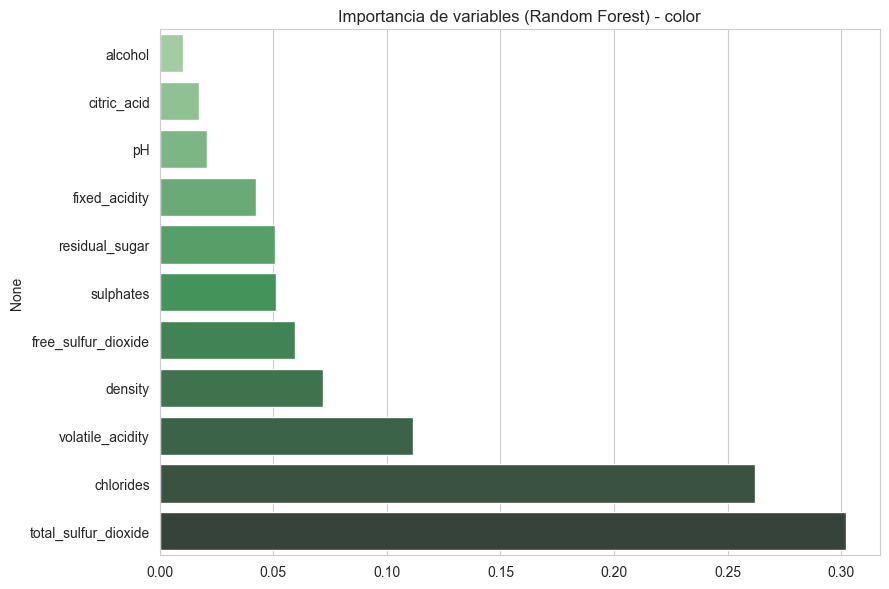

In [21]:
imp = pd.Series(rf_color.feature_importances_, index=features).sort_values()
plt.figure(figsize=(9, 6))
sns.barplot(x=imp.values, y=imp.index, palette="Greens_d")
plt.title("Importancia de variables (Random Forest) - color")
plt.tight_layout()
plt.show()

## 5. Modelo de calidad

Mismos modelos con class_weight balanced; sumamos MAE y accuracy con tolerancia.

In [22]:
from sklearn.metrics import mean_absolute_error

def acc_tol1(y_true, y_pred):
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)) <= 1)

modelos_qual = {
    "LogReg": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "RandomForest": RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=42),
}

filas = []
modelos_fit = {}
for nombre, m in modelos_qual.items():
    cv = cross_val_score(m, Xq_tr_s, yq_tr, cv=5, scoring="f1_macro").mean()
    m.fit(Xq_tr_s, yq_tr)
    modelos_fit[nombre] = m
    pred = m.predict(Xq_te_s)
    filas.append({"modelo": nombre,
                  "cv_f1": round(cv, 4),
                  "accuracy": round(accuracy_score(yq_te, pred), 4),
                  "f1_macro": round(f1_score(yq_te, pred, average="macro"), 4),
                  "mae": round(mean_absolute_error(yq_te, pred), 4),
                  "acc_tol1": round(acc_tol1(yq_te, pred), 4)})
tabla_qual = pd.DataFrame(filas).sort_values("f1_macro", ascending=False).reset_index(drop=True)
tabla_qual

,modelo,cv_f1,accuracy,f1_macro,mae,acc_tol1
0,RandomForest,0.4503,0.8017,0.4595,0.1983,1.0000
1,LogReg,0.4449,0.5188,0.4409,0.4897,0.9915
2,KNN,0.4408,0.7904,0.4363,0.2105,0.9991


In [23]:
best_q = tabla_qual.iloc[0]["modelo"]
mq = modelos_fit[best_q]
pred_q = mq.predict(Xq_te_s)
print("Mejor modelo:", best_q)
print(classification_report(yq_te, pred_q, target_names=niveles))

Mejor modelo: RandomForest
              precision    recall  f1-score   support

        baja       1.00      0.02      0.04        47
       media       0.81      0.96      0.88       815
        alta       0.68      0.34      0.46       202

    accuracy                           0.80      1064
   macro avg       0.83      0.44      0.46      1064
weighted avg       0.80      0.80      0.76      1064



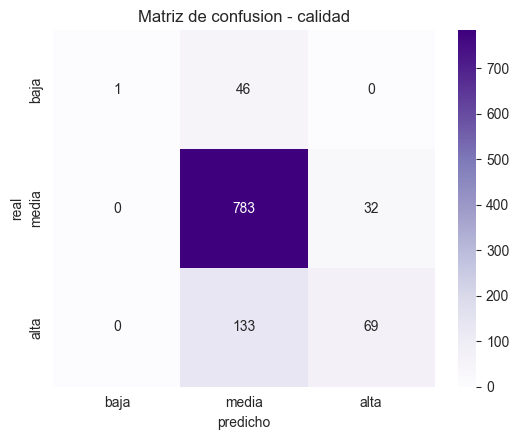

In [24]:
cm = confusion_matrix(yq_te, pred_q)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=niveles, yticklabels=niveles)
plt.title("Matriz de confusion - calidad")
plt.ylabel("real"); plt.xlabel("predicho")
plt.tight_layout()
plt.show()

### Variables mas importantes para la calidad

/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_24026/3217870135.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp_q.values, y=imp_q.index, palette="Purples_d")


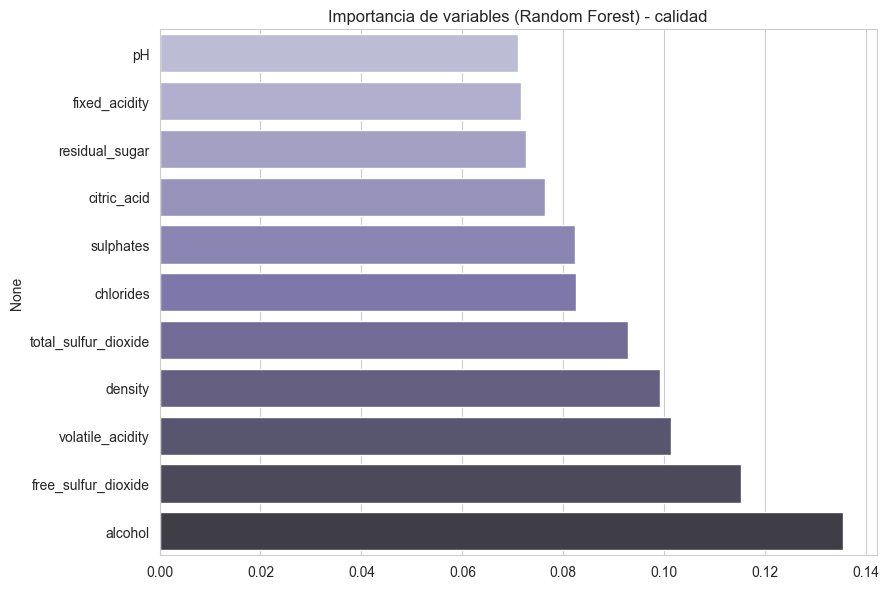

In [25]:
rf_qual = modelos_fit["RandomForest"]
imp_q = pd.Series(rf_qual.feature_importances_, index=features).sort_values()
plt.figure(figsize=(9, 6))
sns.barplot(x=imp_q.values, y=imp_q.index, palette="Purples_d")
plt.title("Importancia de variables (Random Forest) - calidad")
plt.tight_layout()
plt.show()

El alcohol manda. Los errores caen en niveles vecinos: la tolerancia da altisimo y el F1 moderado.

## 6. Conclusiones

Color casi perfecto con pura quimica; calidad solo aproximada, dominada por el alcohol. Siguen los next steps con redes.

## 7. Redes neuronales (next steps)

Red secuencial, autoencoder y modelo funcional multi-salida.

### Red secuencial para el color

In [26]:
net_color = keras.Sequential([
    layers.Input(shape=(len(features),)),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])
net_color.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
hist_c = net_color.fit(Xc_tr_s, yc_tr, validation_split=0.2, epochs=40, batch_size=64, verbose=0)
loss_c, acc_c = net_color.evaluate(Xc_te_s, yc_te, verbose=0)
round(acc_c, 4)

0.9953

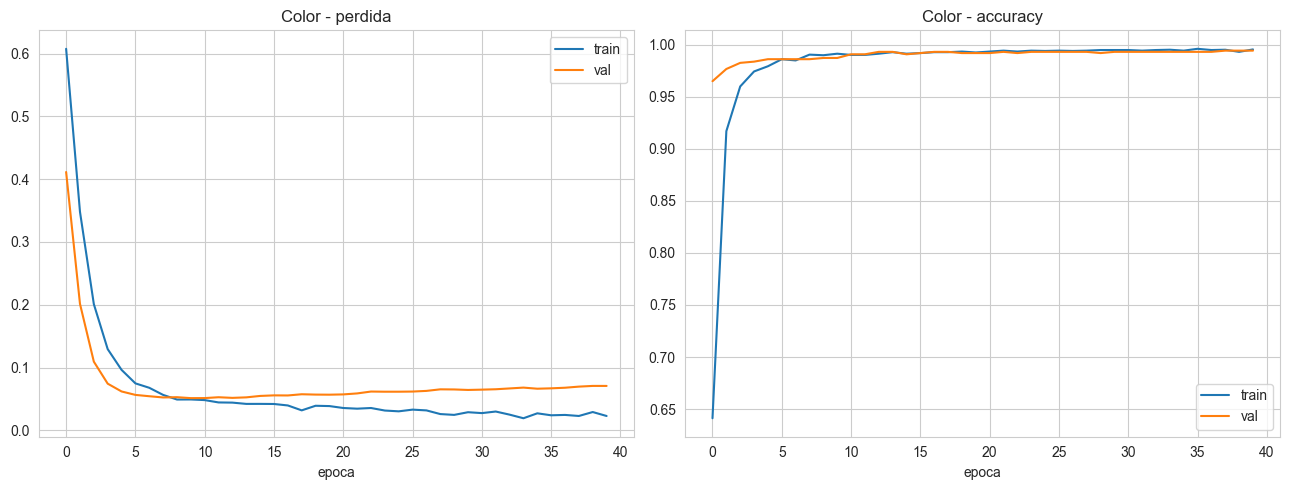

In [27]:
plt.figure(figsize=(13, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_c.history["loss"], label="train")
plt.plot(hist_c.history["val_loss"], label="val")
plt.title("Color - perdida"); plt.xlabel("epoca"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(hist_c.history["accuracy"], label="train")
plt.plot(hist_c.history["val_accuracy"], label="val")
plt.title("Color - accuracy"); plt.xlabel("epoca"); plt.legend()
plt.tight_layout()
plt.show()

### Red secuencial para la calidad

Tres salidas (softmax) y pesos por clase.

In [28]:
clases = np.unique(yq_tr)
pesos = len(yq_tr) / (len(clases) * np.bincount(yq_tr))
class_weight = {int(c): float(w) for c, w in zip(clases, pesos)}

net_qual = keras.Sequential([
    layers.Input(shape=(len(features),)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax"),
])
net_qual.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_q = net_qual.fit(Xq_tr_s, yq_tr, validation_split=0.2, epochs=60, batch_size=64,
                      class_weight=class_weight, verbose=0)
pred_nq = net_qual.predict(Xq_te_s, verbose=0).argmax(axis=1)
{"accuracy": round(accuracy_score(yq_te, pred_nq), 4),
 "f1_macro": round(f1_score(yq_te, pred_nq, average="macro"), 4),
 "mae": round(mean_absolute_error(yq_te, pred_nq), 4),
 "acc_tol1": round(acc_tol1(yq_te, pred_nq), 4)}

{'accuracy': 0.5733, 'f1_macro': 0.4827, 'mae': 0.4352, 'acc_tol1': 0.9915}

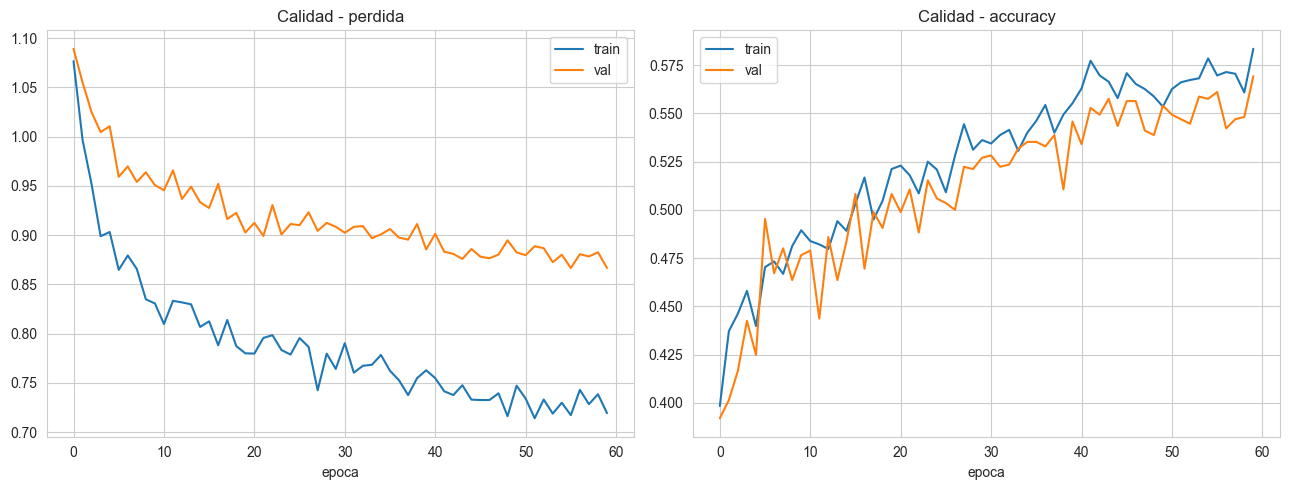

In [29]:
plt.figure(figsize=(13, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_q.history["loss"], label="train")
plt.plot(hist_q.history["val_loss"], label="val")
plt.title("Calidad - perdida"); plt.xlabel("epoca"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(hist_q.history["accuracy"], label="train")
plt.plot(hist_q.history["val_accuracy"], label="val")
plt.title("Calidad - accuracy"); plt.xlabel("epoca"); plt.legend()
plt.tight_layout()
plt.show()

Sin overfitting marcado; si apareciera, subiriamos el Dropout o usariamos early stopping.

### Autoencoder

Barremos la dimension latente y miramos el error de reconstruccion.

In [30]:
def autoencoder(dim, X_tr, X_te):
    inp = keras.Input(shape=(X_tr.shape[1],))
    h = layers.Dense(8, activation="relu")(inp)
    z = layers.Dense(dim, activation="relu", name="latente")(h)
    h2 = layers.Dense(8, activation="relu")(z)
    out = layers.Dense(X_tr.shape[1], activation="linear")(h2)
    ae = keras.Model(inp, out)
    ae.compile(optimizer="adam", loss="mse")
    ae.fit(X_tr, X_tr, validation_split=0.2, epochs=40, batch_size=64, verbose=0)
    return ae.evaluate(X_te, X_te, verbose=0), ae

dims = [1, 2, 3, 4, 5, 6, 8, 11]
mse = {}
modelos_ae = {}
for d in dims:
    m, ae = autoencoder(d, Xq_tr_s, Xq_te_s)
    mse[d] = round(float(m), 4)
    modelos_ae[d] = ae
mse

{1: 0.6506,
 2: 0.4086,
 3: 0.3509,
 4: 0.2776,
 5: 0.2221,
 6: 0.2312,
 8: 0.114,
 11: 0.1262}

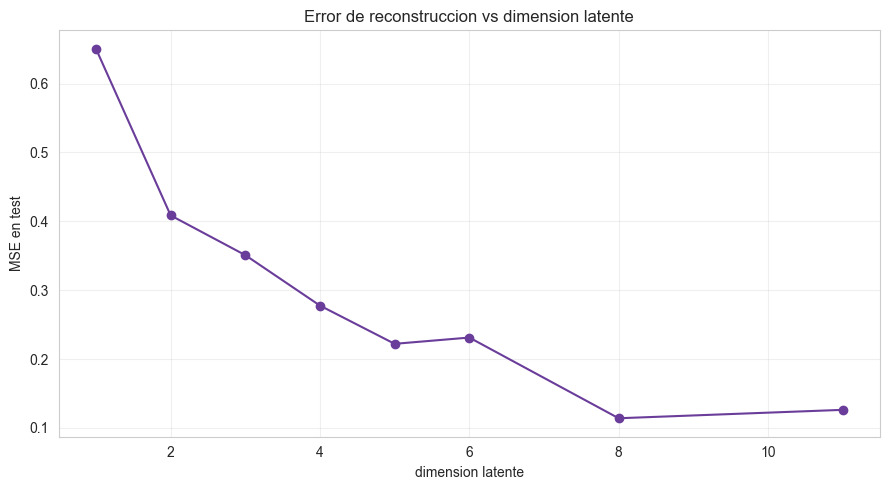

In [31]:
plt.figure(figsize=(9, 5))
plt.plot(list(mse.keys()), list(mse.values()), "o-", color="#6a3d9a")
plt.title("Error de reconstruccion vs dimension latente")
plt.xlabel("dimension latente"); plt.ylabel("MSE en test")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
ae3 = modelos_ae[3]
encoder = keras.Model(ae3.input, ae3.get_layer("latente").output)
Z = encoder.predict(Xq_te_s, verbose=0)
df_lat = pd.DataFrame(Z[:, :2], columns=["z1", "z2"])
df_lat["calidad"] = pd.Series(yq_te).map(dict(enumerate(niveles))).values
fig = px.scatter(df_lat, x="z1", y="z2", color="calidad",
                 title="Espacio latente del autoencoder (dim 3)", opacity=0.6)
fig.update_traces(marker_size=5)
fig.show()

El error cae fuerte hasta 3-5 dimensiones y despues se aplana: con la mitad de las variables se reconstruye casi sin perdida.

Esto cierra con lo que vimos en el punto 1: el heatmap de Pearson ya mostraba pares bastante correlacionados (SO2 libre con SO2 total, densidad con azucar residual y con alcohol), o sea que las 11 variables no son del todo independientes y hay informacion repetida. Cuando hay esa redundancia tiene sentido reducir dimensionalidad, porque varias columnas se pueden resumir en menos ejes sin tirar mucho. El autoencoder confirma esa lectura: encuentra una representacion mas chica (unas 5 dimensiones) que recupera casi toda la senal, justamente porque parte de lo que sobra ya estaba correlacionado.

### Modelo funcional multi-salida

Tronco compartido con dos salidas; rehacemos un split para alinear etiquetas.

In [33]:
idx = np.arange(len(df))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, stratify=y_qual, random_state=42)

scaler_f = StandardScaler().fit(X_qual[idx_tr])
Xf_tr = scaler_f.transform(X_qual[idx_tr])
Xf_te = scaler_f.transform(X_qual[idx_te])
yc_tr_f, yc_te_f = y_color[idx_tr], y_color[idx_te]
yq_tr_f, yq_te_f = y_qual[idx_tr], y_qual[idx_te]

inp = keras.Input(shape=(len(features),))
x = layers.Dense(64, activation="relu")(inp)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation="relu")(x)
sal_color = layers.Dense(1, activation="sigmoid", name="color")(x)
sal_qual = layers.Dense(3, activation="softmax", name="calidad")(x)

modelo_func = keras.Model(inputs=inp, outputs=[sal_color, sal_qual])
modelo_func.compile(optimizer="adam",
                    loss={"color": "binary_crossentropy", "calidad": "sparse_categorical_crossentropy"},
                    metrics={"color": "accuracy", "calidad": "accuracy"})
hist_f = modelo_func.fit(Xf_tr, {"color": yc_tr_f, "calidad": yq_tr_f},
                         validation_split=0.2, epochs=60, batch_size=64, verbose=0)
p_color, p_qual = modelo_func.predict(Xf_te, verbose=0)
p_color = (p_color.ravel() > 0.5).astype(int)
p_qual = p_qual.argmax(axis=1)
{"color_acc": round(accuracy_score(yc_te_f, p_color), 4),
 "calidad_acc": round(accuracy_score(yq_te_f, p_qual), 4),
 "calidad_f1": round(f1_score(yq_te_f, p_qual, average="macro"), 4),
 "calidad_acc_tol1": round(acc_tol1(yq_te_f, p_qual), 4)}

{'color_acc': 0.9953,
 'calidad_acc': 0.7838,
 'calidad_f1': 0.4842,
 'calidad_acc_tol1': 0.9991}

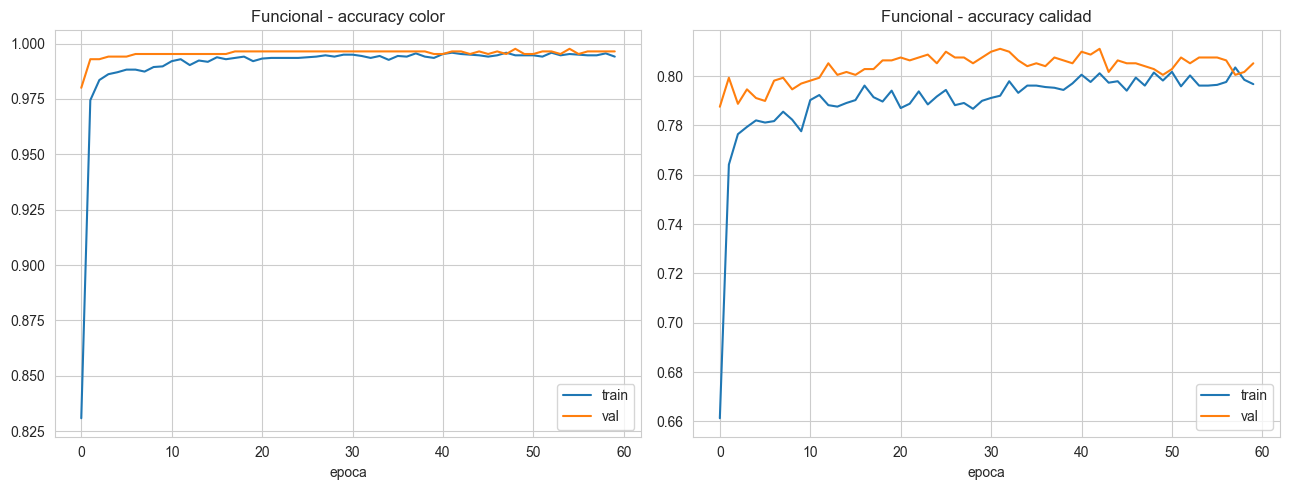

In [34]:
plt.figure(figsize=(13, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_f.history["color_accuracy"], label="train")
plt.plot(hist_f.history["val_color_accuracy"], label="val")
plt.title("Funcional - accuracy color"); plt.xlabel("epoca"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(hist_f.history["calidad_accuracy"], label="train")
plt.plot(hist_f.history["val_calidad_accuracy"], label="val")
plt.title("Funcional - accuracy calidad"); plt.xlabel("epoca"); plt.legend()
plt.tight_layout()
plt.show()

### Comparacion final

In [35]:
comparativa = pd.DataFrame([
    {"enfoque": "Clasico (RF)", "color_acc": tabla_color.iloc[0]["accuracy"],
     "calidad_acc": tabla_qual.iloc[0]["accuracy"], "calidad_f1": tabla_qual.iloc[0]["f1_macro"]},
    {"enfoque": "Redes secuenciales", "color_acc": round(acc_c, 4),
     "calidad_acc": round(accuracy_score(yq_te, pred_nq), 4),
     "calidad_f1": round(f1_score(yq_te, pred_nq, average="macro"), 4)},
    {"enfoque": "Modelo funcional", "color_acc": round(accuracy_score(yc_te_f, p_color), 4),
     "calidad_acc": round(accuracy_score(yq_te_f, p_qual), 4),
     "calidad_f1": round(f1_score(yq_te_f, p_qual, average="macro"), 4)},
])
comparativa

,enfoque,color_acc,calidad_acc,calidad_f1
0,Clasico (RF),0.9944,0.8017,0.4595
1,Redes secuenciales,0.9953,0.5733,0.4827
2,Modelo funcional,0.9953,0.7838,0.4842


Todos coinciden: color trivial, calidad solo aproximada. El funcional resuelve las dos tareas a la vez y rinde a la par.